# COMP219
## Lab 3
In the first two weeks of labs, we introduced notebooks and performed some basic visualisation. This week, we will look at implementing ID3 (iterative dichotomiser 3), a variant of the decision tree algorithm.


### Getting Set Up
We will need various libraries for today's lab, let's import them. We will also import the diabetes dataset, found [here](https://github.com/plotly/datasets/blob/master/diabetes.csv). You do not need to have any medical (or similar) background. However, for context, we are looking to predict diabetes in individuals based on a score called the diabetes pedigree. There are many factors, such as glucose, age, and so on (see the column names in the dataset) that can help us predict the individual's diabetes status. 

In [1]:
import pandas as pd 
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree 
import matplotlib.pyplot as plt 
import math

dataset = pd.read_csv('diabetes.csv') 
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Implementing ID3
In the lectures, we covered how ID3 works. Recall that:
- ID3's splitting criterion is based on information gain
- It can only handle categorical (discrete) values
- It cannot handle missing values
- It performs no pruning
- It is susceptible to outliers.

#### Entropy and Information Gain

We need to calculate entropy, which will help us measure the amount of uncertainty (impurity) in the data. This will guide us during the construction of the tree by determining the best attribute for splitting at each step.

The process of splitting is done by calculating information gain. We are looking to maximise information gain at each split to minimise uncertainty and maximise homogeneity in the resulting subsets of data.

In [2]:
#Entropy calculation
def calculate_entropy(data, target_column): 
	total_rows = len(data) 
	target_values = data[target_column].unique() 

	entropy = 0
	for value in target_values: 
		#Proportion of instances with current value
		value_count = len(data[data[target_column] == value]) 
		proportion = value_count / total_rows 
		entropy -= proportion * math.log2(proportion) if proportion != 0 else 0 #see slide 20 for written formula

	return entropy 

#Information gain calculation
def calculate_information_gain(data, feature, target_column): 
	#Weighted average entropy of feature
	unique_values = data[feature].unique() 
	weighted_entropy = 0

	for value in unique_values: 
		subset = data[data[feature] == value] 
		proportion = len(subset) / len(data) 
		weighted_entropy += proportion * calculate_entropy(subset, target_column) 

	information_gain = outcome_entr - weighted_entropy 

	return information_gain

#### ID3 In Detail

The third function we need to define is one that builds the ID3. First, we check if the target feature has a single unique value (it should not). We then check if all features have been used or if the remaining features provide no more information gain. Feature selection is done based on information gain - we choose the feature with the highest information gain. We then proceed to create a subtree for that feature. We then split the best feature to build further subtrees for each of its unique values.

In [3]:
#ID3 implementation
def id3(data, target_column, features): 
	if len(data[target_column].unique()) == 1: 
		return data[target_column].iloc[0] 


	if len(features) == 0: 
		return data[target_column].mode().iloc[0] 

	best_feature = max(features, key=lambda x: calculate_information_gain(data, x, target_column)) 

	tree = {best_feature: {}} 

	features = [f for f in features if f != best_feature] 

	for value in data[best_feature].unique(): 
		subset = data[data[best_feature] == value] 
		tree[best_feature][value] = id3(subset, target_column, features) 

	return tree 

In [4]:
outcome_entr = calculate_entropy(dataset, 'Outcome') 
print(f"Entropy of the dataset: {outcome_entr}")

Entropy of the dataset: 0.9331343166407831


Pregnancies - Entropy: 3.482, Information Gain: 0.062
Glucose - Entropy: 6.751, Information Gain: 0.304
BloodPressure - Entropy: 4.792, Information Gain: 0.059
SkinThickness - Entropy: 4.586, Information Gain: 0.082
Insulin - Entropy: 4.682, Information Gain: 0.277
BMI - Entropy: 7.594, Information Gain: 0.344
DiabetesPedigreeFunction - Entropy: 8.829, Information Gain: 0.651
Age - Entropy: 5.029, Information Gain: 0.141


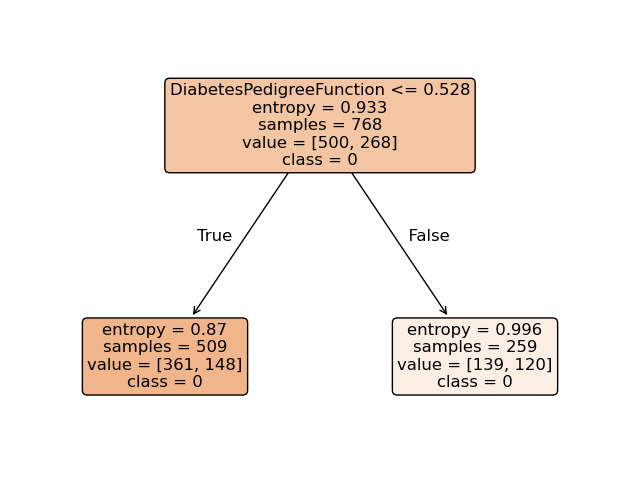

In [5]:
for column in dataset.columns[:-1]: 
	entropy = calculate_entropy(dataset, column) 
	information_gain = calculate_information_gain(dataset, column, 'Outcome') 
	print(f"{column} - Entropy: {entropy:.3f}, Information Gain: {information_gain:.3f}")

# Feature selection for the first step in making decision tree 
selected_feature = 'DiabetesPedigreeFunction'

# Create a decision tree 
clf = DecisionTreeClassifier(criterion='entropy', max_depth=1) 
X = dataset[[selected_feature]] 
y = dataset['Outcome'] 
clf.fit(X, y) 

plt.figure(figsize=(8, 6)) 
plot_tree(clf, feature_names=[selected_feature], class_names=['0', '1'], filled=True, rounded=True) 
plt.show() 

### Adversarial Attack: Data Poisoning
The process of data poisoning involves falsifying a small portion of the labels. In our case, the value of the target feature is "flipped" - for example, we replace a 1 with a 0 (or a 0 becomes a 1). It is a very simple strategy which can have a significant impact on our model's accuracy. Let's flip 5% of the labels.

The below implementation of a data poisoning attack is an adversarial attack based on the example in Chapter 5.9.2.2 of the book.

Original class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Poisoned data saved to diabetes_poisoned.csv

New class distribution after poisoning:
Outcome
0    490
1    278
Name: count, dtype: int64



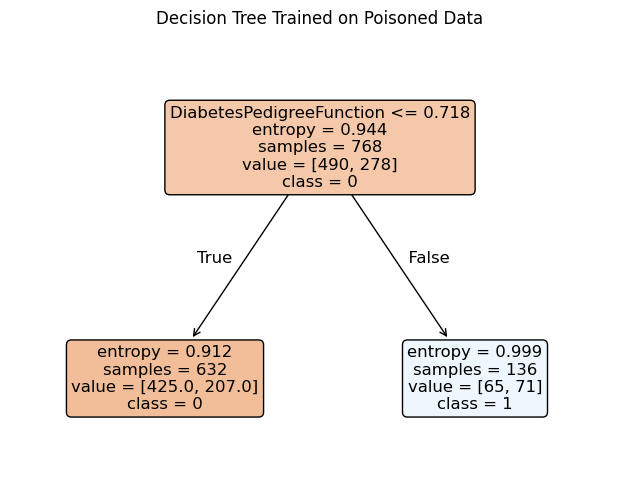

In [6]:
#Original dataset distribution
print(f"Original class distribution:\n{dataset['Outcome'].value_counts()}\n")

#Set the percentage of data to poison
poisoning_percentage = 0.05  #5% of the data will be poisoned
num_samples_to_poison = int(len(dataset) * poisoning_percentage)

#Randomly select rows to poison
np.random.seed(42)
poison_indices = np.random.choice(dataset.index, num_samples_to_poison, replace=False)

#Flip the labels for the selected rows
dataset.loc[poison_indices, 'Outcome'] = 1 - dataset.loc[poison_indices, 'Outcome']

#Save the poisoned dataset
poisoned_filename = 'diabetes_poisoned.csv'
dataset.to_csv(poisoned_filename, index=False)
print(f"Poisoned data saved to {poisoned_filename}\n")

#Print the new class distribution
print(f"New class distribution after poisoning:\n{dataset['Outcome'].value_counts()}\n")

#Use the poisoned data to train the model
data_poisoned = pd.read_csv(poisoned_filename)
X = data_poisoned[['DiabetesPedigreeFunction']]  # Using the same feature for simplicity
y = data_poisoned['Outcome']

#Train a decision tree classifier on the poisoned data
clf_poisoned = DecisionTreeClassifier(criterion='entropy', max_depth=1)
clf_poisoned.fit(X, y)

#Plot the decision tree
plt.figure(figsize=(8, 6))
plot_tree(clf_poisoned, feature_names=['DiabetesPedigreeFunction'], class_names=['0', '1'], filled=True, rounded=True)
plt.title("Decision Tree Trained on Poisoned Data")
plt.show()


## The Task
In this lab, we constructed a decision tree and performed a data poisoning attack. Your task is simple: visualise both the original dataset (stored in the variable "dataset") and the poisoned dataset (stored in the variable "data_poisoned").

First, perform some diagnostics on the model when fitted on each dataset. Inspect the following:
- accuracy score
- precision score
- recall
- F1-score
- confusion matrix

You can find information on accuracy score, precision score, recall, F1-score, and confusion matrix [here](https://www.geeksforgeeks.org/confusion-matrix-machine-learning/).

Other useful metrics are the Receiver-operating characteristic curve and the area under the curve, however, these will be covered later in the module.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score

#your code goes here
